# Dependencies

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Data Loading

In [3]:
def txt_to_pd(file_path):
    """
    Load data from a .txt file and convert into a pandas DataFrame
    Args: 
        file_path (string): Path location of the file to be converted
    Returns:
        df (DataFrame): converted dataframe with index set to "Unit Number"
    """
    
    delimiter = " "

    df = pd.read_csv(file_path, 
               delimiter=delimiter, 
               header=None,
               encoding='utf-8')
    df = df.dropna(axis=1)
    df.columns = ["Unit Number", "Time, in cycles", "Operational Setting 1", "Operational Setting 2", "Operational Setting 3", "Sensor Measurement 1",
              "Sensor Measurement 2", "Sensor Measurement 3", "Sensor Measurement 4", "Sensor Measurement 5", "Sensor Measurement 6", "Sensor Measurement 7", 
              "Sensor Measurement 8", "Sensor Measurement 9", "Sensor Measurement 10", "Sensor Measurement 11", "Sensor Measurement 12", "Sensor Measurement 13", 
              "Sensor Measurement 14", "Sensor Measurement 15", "Sensor Measurement 16", "Sensor Measurement 17", "Sensor Measurement 18", "Sensor Measurement 19", 
              "Sensor Measurement 20", "Sensor Measurement 21"]
    df = df.set_index("Unit Number")
    return df

In [4]:
# Load training and test data
train = txt_to_pd("data/Challenge_Data/train.txt")
test = txt_to_pd("data/Challenge_Data/test.txt")

In [5]:
train.head()

,"Time, in cycles",Operational Setting 1,Operational Setting 2,Operational Setting 3,Sensor Measurement 1,Sensor Measurement 2,Sensor Measurement 3,Sensor Measurement 4,Sensor Measurement 5,Sensor Measurement 6,...,Sensor Measurement 12,Sensor Measurement 13,Sensor Measurement 14,Sensor Measurement 15,Sensor Measurement 16,Sensor Measurement 17,Sensor Measurement 18,Sensor Measurement 19,Sensor Measurement 20,Sensor Measurement 21
Unit Number,,,,,,,,,,,,,,,,,,,,,
1,1,10.0047,0.2501,20.0,489.05,604.13,1499.45,1309.95,10.52,15.49,...,372.15,2388.13,8120.83,8.6216,0.03,368,2319,100.0,28.58,17.1735
1,2,0.0015,0.0003,100.0,518.67,642.13,1584.55,1403.96,14.62,21.61,...,521.81,2388.15,8132.87,8.3907,0.03,391,2388,100.0,38.99,23.3619
1,3,34.9986,0.8401,60.0,449.44,555.42,1368.17,1122.49,5.48,8.00,...,183.26,2387.95,8063.84,9.3557,0.02,334,2223,100.0,14.83,8.8555
1,4,20.0031,0.7005,0.0,491.19,607.03,1488.44,1249.18,9.35,13.65,...,314.84,2388.07,8052.30,9.2231,0.02,364,2324,100.0,24.42,14.7832
1,5,42.0041,0.8405,40.0,445.00,549.52,1354.48,1124.32,3.91,5.71,...,130.44,2387.89,8083.67,9.2986,0.02,330,2212,100.0,10.99,6.4025


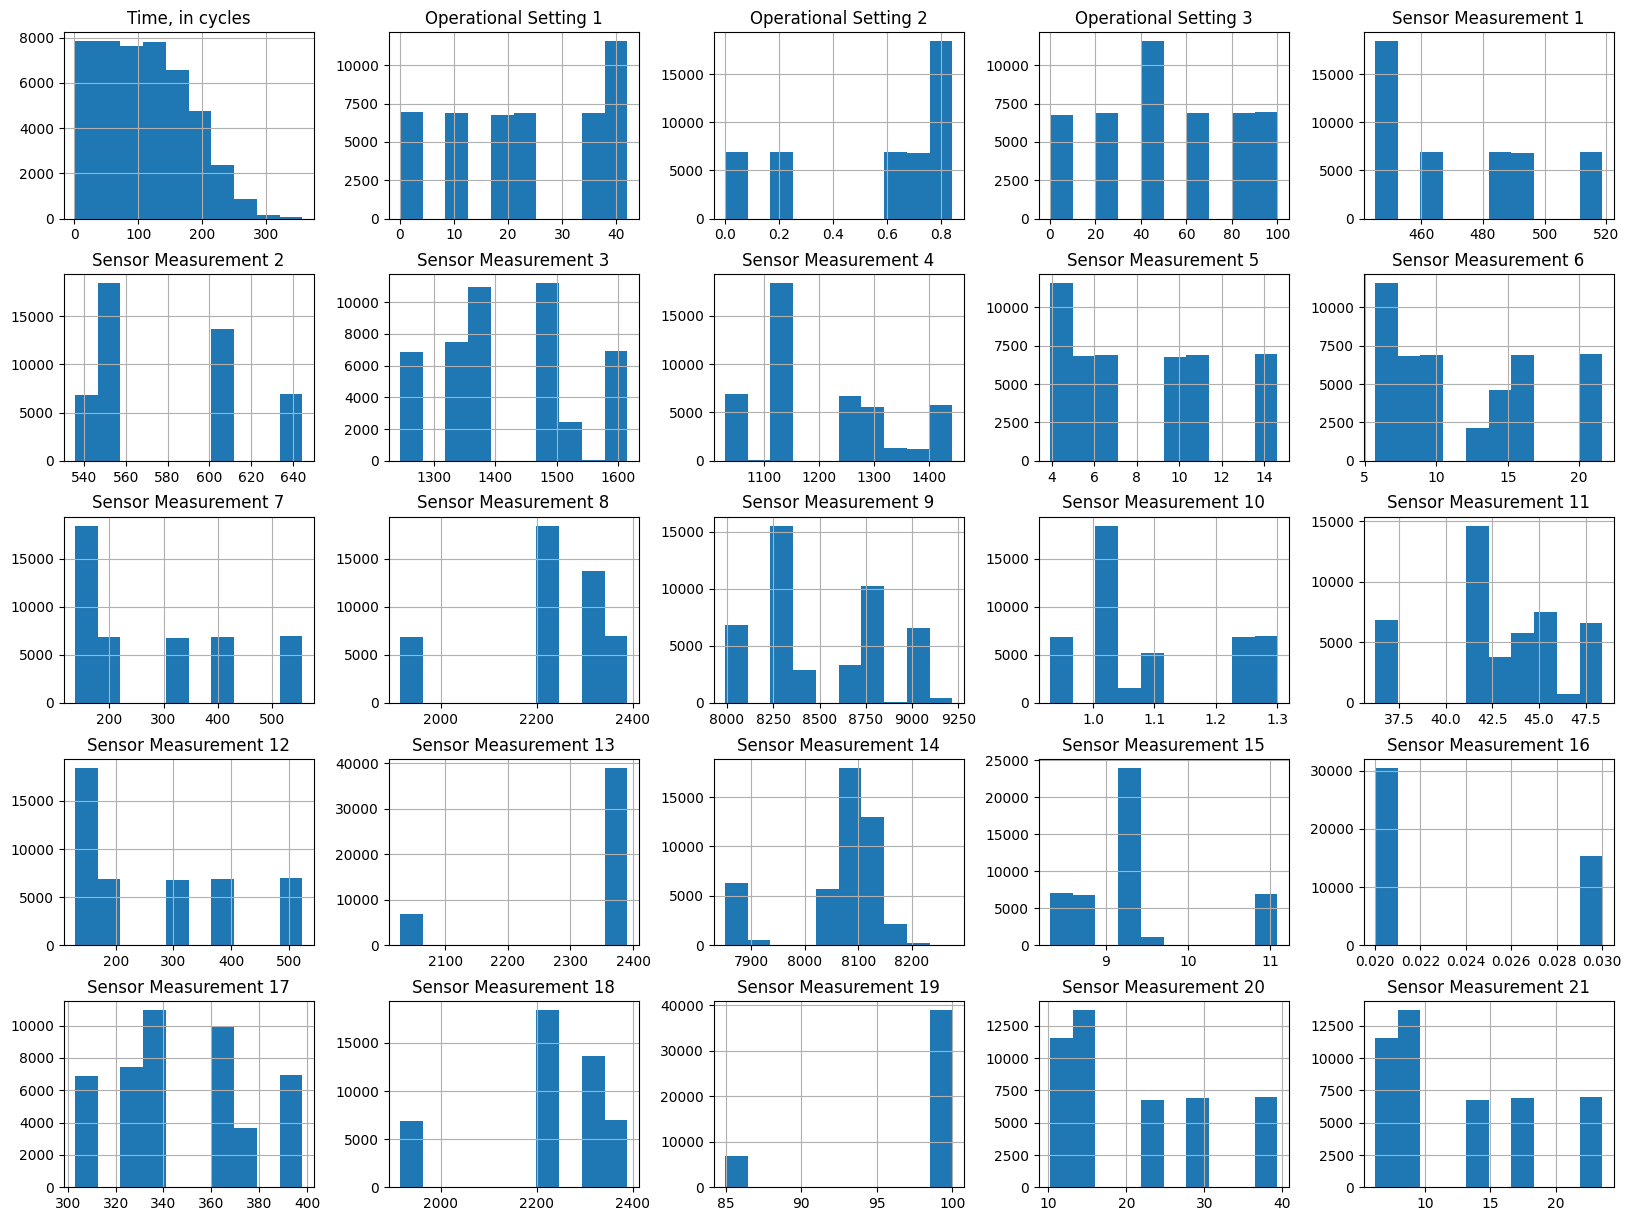

In [6]:
train.hist(bins=10, figsize=(20,15))
plt.show()

In [7]:
test.head()

,"Time, in cycles",Operational Setting 1,Operational Setting 2,Operational Setting 3,Sensor Measurement 1,Sensor Measurement 2,Sensor Measurement 3,Sensor Measurement 4,Sensor Measurement 5,Sensor Measurement 6,...,Sensor Measurement 12,Sensor Measurement 13,Sensor Measurement 14,Sensor Measurement 15,Sensor Measurement 16,Sensor Measurement 17,Sensor Measurement 18,Sensor Measurement 19,Sensor Measurement 20,Sensor Measurement 21
Unit Number,,,,,,,,,,,,,,,,,,,,,
1,1,0.0016,0.0002,100.0,518.67,642.88,1587.21,1412.44,14.62,21.61,...,521.44,2388.10,8124.04,8.4363,0.03,393,2388,100.00,38.97,23.3029
1,2,24.9993,0.6215,80.0,462.54,536.45,1262.64,1055.44,7.05,9.02,...,164.32,2027.95,7865.20,10.8935,0.02,308,1915,84.93,14.29,8.6686
1,3,0.0004,0.0000,100.0,518.67,642.65,1589.75,1409.54,14.62,21.61,...,521.15,2388.19,8121.12,8.4620,0.03,393,2388,100.00,38.91,23.2693
1,4,10.0034,0.2500,20.0,489.05,604.44,1499.93,1315.34,10.52,15.49,...,371.42,2388.21,8123.53,8.6815,0.03,369,2319,100.00,28.60,17.0930
1,5,0.0024,0.0011,100.0,518.67,642.74,1585.47,1408.12,14.62,21.61,...,520.86,2388.13,8118.30,8.4617,0.03,392,2388,100.00,38.82,23.3124


# Data Exploration and Pre-processing

## Data Exploration

In [8]:
# Get Actual Remaining Life
unique_list = train.index.unique().tolist()
len(unique_list)
for i in range(len(unique_list)):
    train.loc[i+1, 'Cycle Max'] = train.loc[i+1]['Time, in cycles'].max()
train['Remaining Life'] = train['Time, in cycles'] - train['Cycle Max']

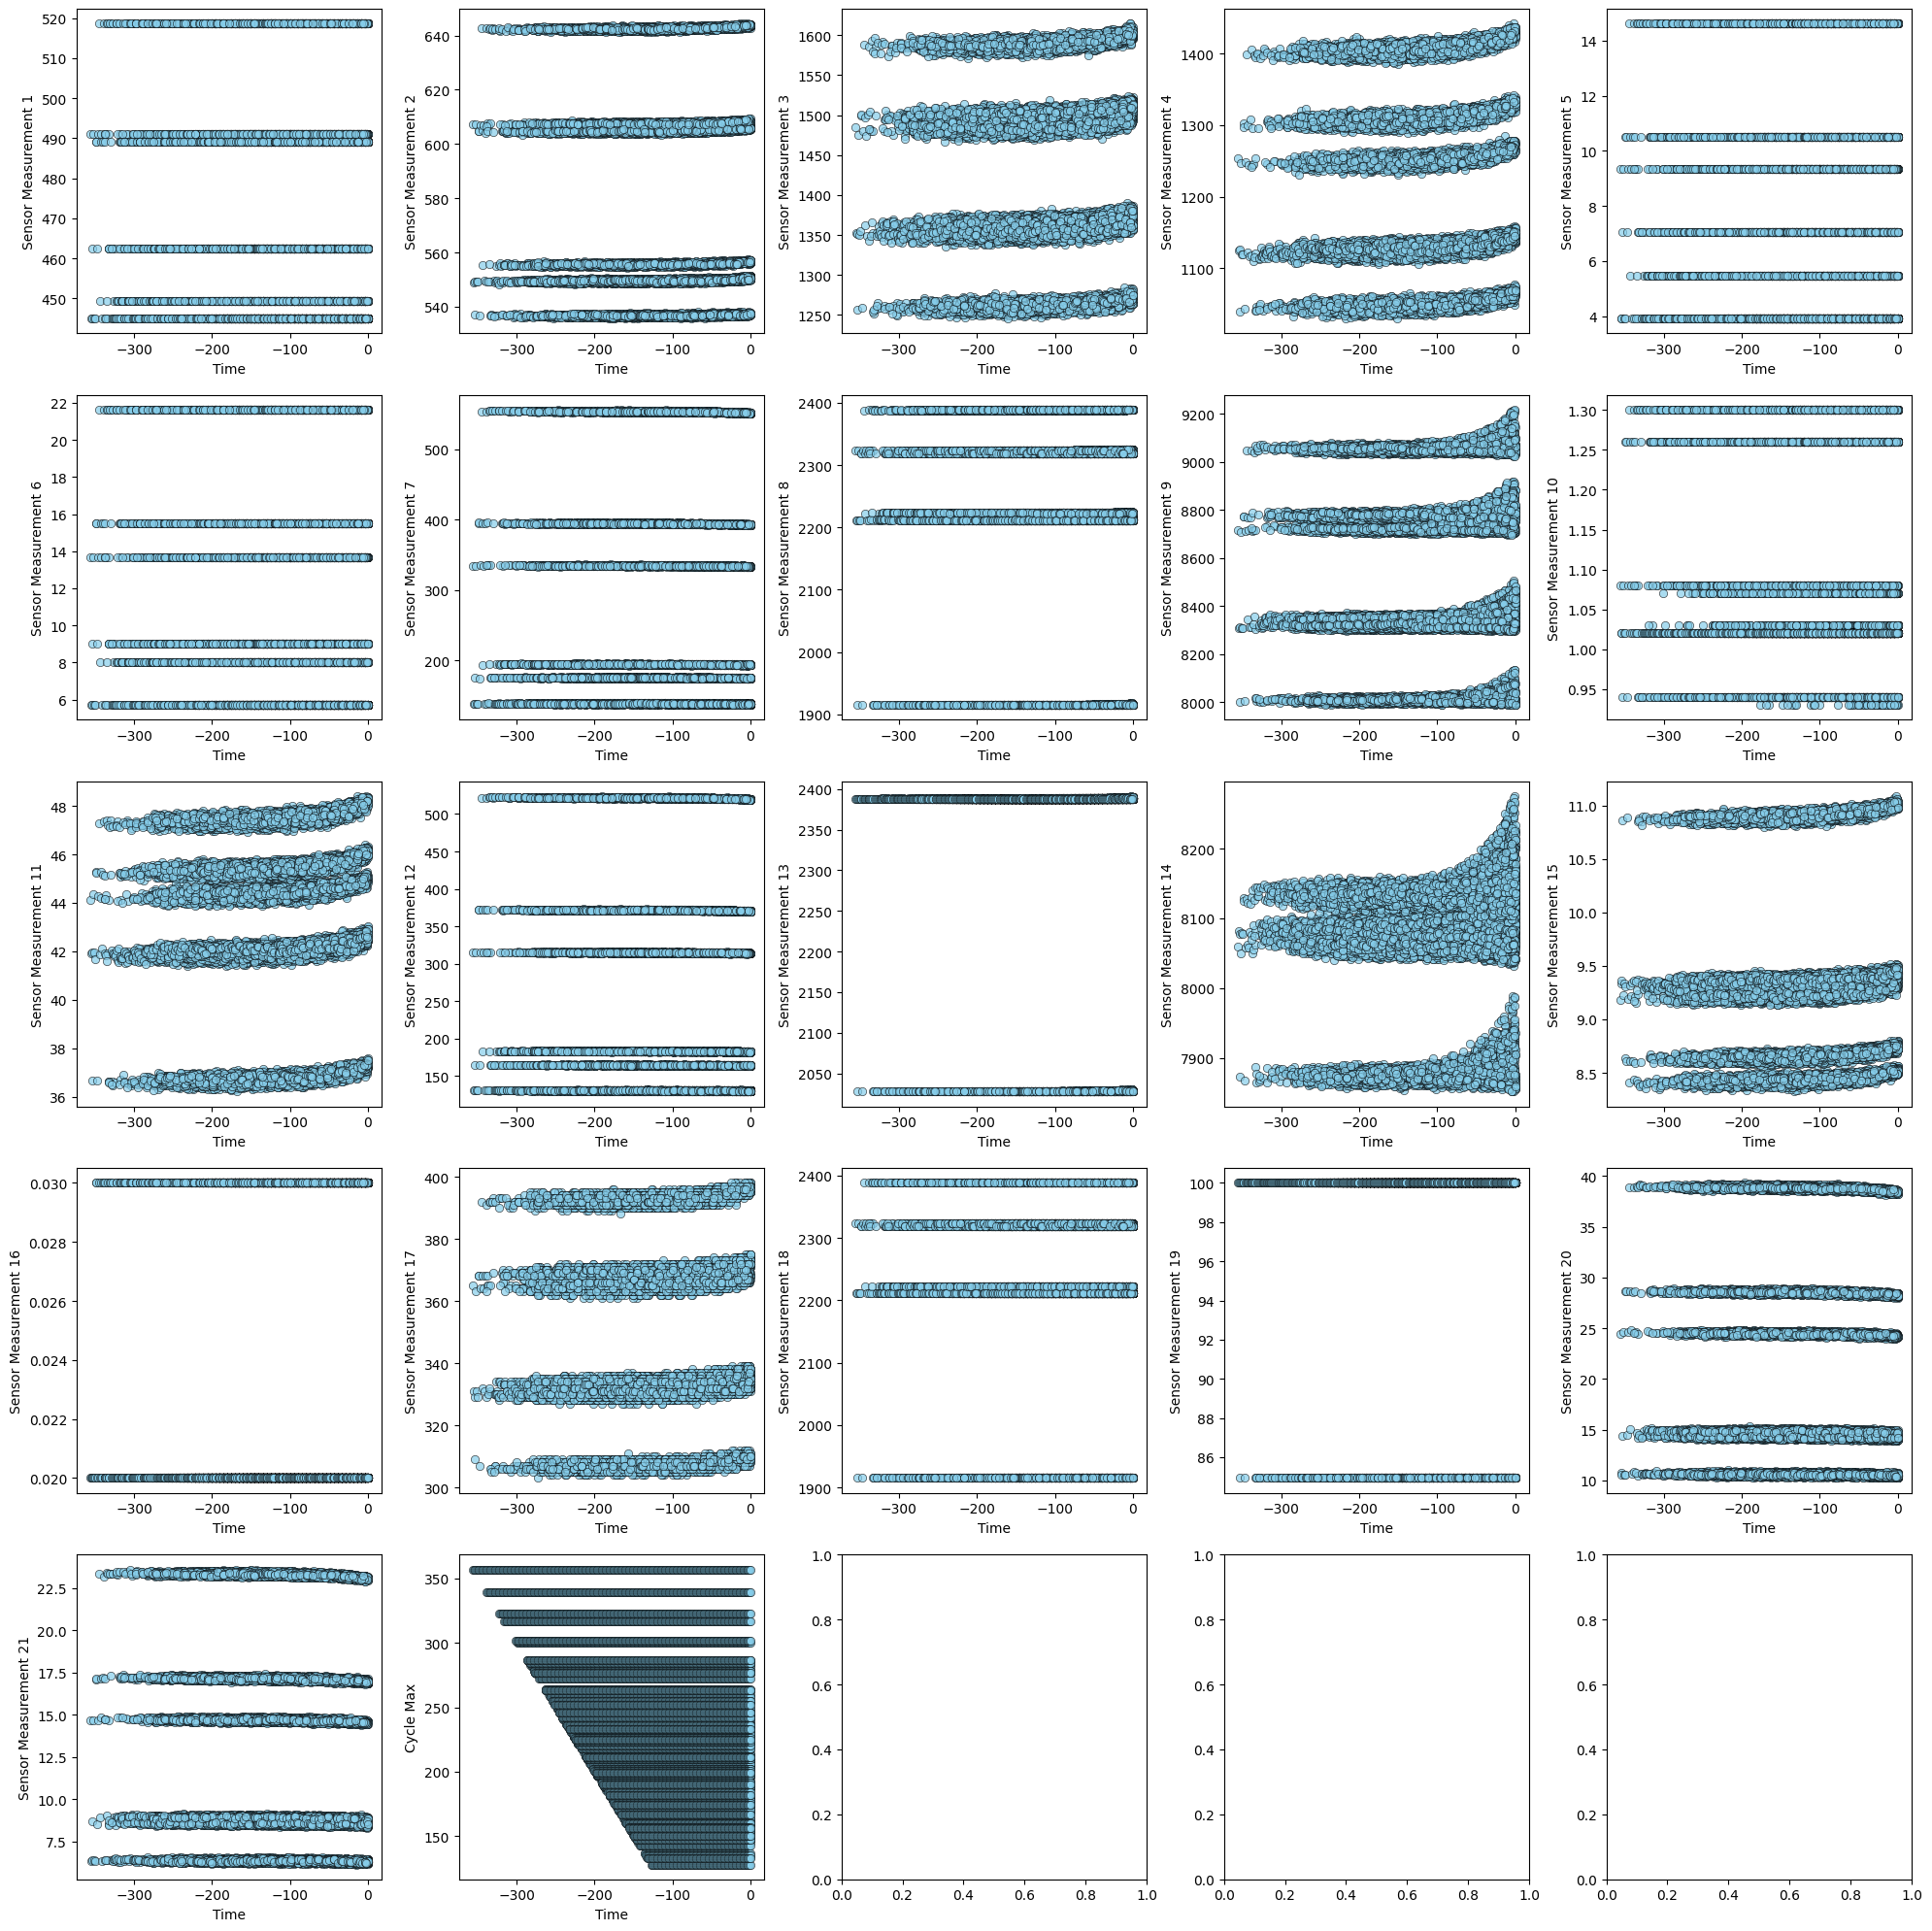

In [9]:
# Plot Remaining Life vs Sensor Measurement of all units and all clusters

fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(20, 20)) 

for i in range(len(train.columns)-5):
    # Scatter plot on the ith subplot on cluster 0
    axs[i//5, i-(i//5)*5].scatter(train['Remaining Life'], train[train.columns[i+4]], 
                   color='skyblue', alpha=0.7, edgecolors='black', linewidths=0.5)
    axs[i//5, i-(i//5)*5].set_xlabel('Time')
    axs[i//5, i-(i//5)*5].set_ylabel(train.columns[i+4])

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

In [10]:
# Get operational data
op_data = train[['Operational Setting 1', 'Operational Setting 2', 'Operational Setting 3']]

In [11]:
# # Get Operating Clusters using unsupervised learning (K-means Clustering)
# # Calculate for silhoutte score to determine optimal K-means clustering
# # Higher silhouette score = better clustering
# scores = []
# for k in range(2, 10):
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     labels = kmeans.fit_predict(op_data)
#     score = silhouette_score(op_data, labels)
#     print("cluster " + str(k) + " - " + str(score))
#     scores.append(score)

[[1.51675295e-03 4.97670406e-04 1.00000000e+02]
 [3.50030533e+01 8.40489284e-01 6.00000000e+01]
 [1.00029627e+01 2.50502528e-01 2.00000000e+01]
 [4.20030440e+01 8.40510423e-01 4.00000000e+01]
 [2.50030126e+01 6.20516407e-01 8.00000000e+01]
 [2.00029465e+01 7.00497164e-01 8.81072992e-13]]


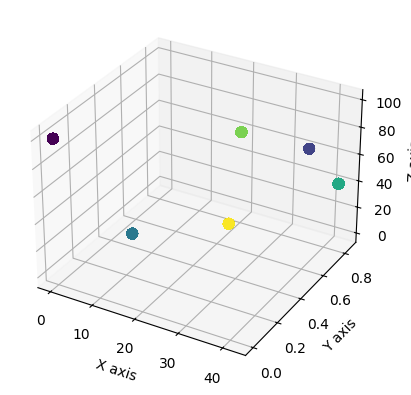

In [12]:
# Create and fit K-Means model using the optimal cluster number (k=6)
kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(op_data)

# Get cluster centers
centers = kmeans.cluster_centers_
print(centers)

# Plot k-clusters 
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Create 3D scatter plot
ax.scatter(op_data[op_data.columns[0]], op_data[op_data.columns[1]], op_data[op_data.columns[2]], c=labels, cmap='viridis', s=50)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.show()

In [13]:
train['cluster'] = labels

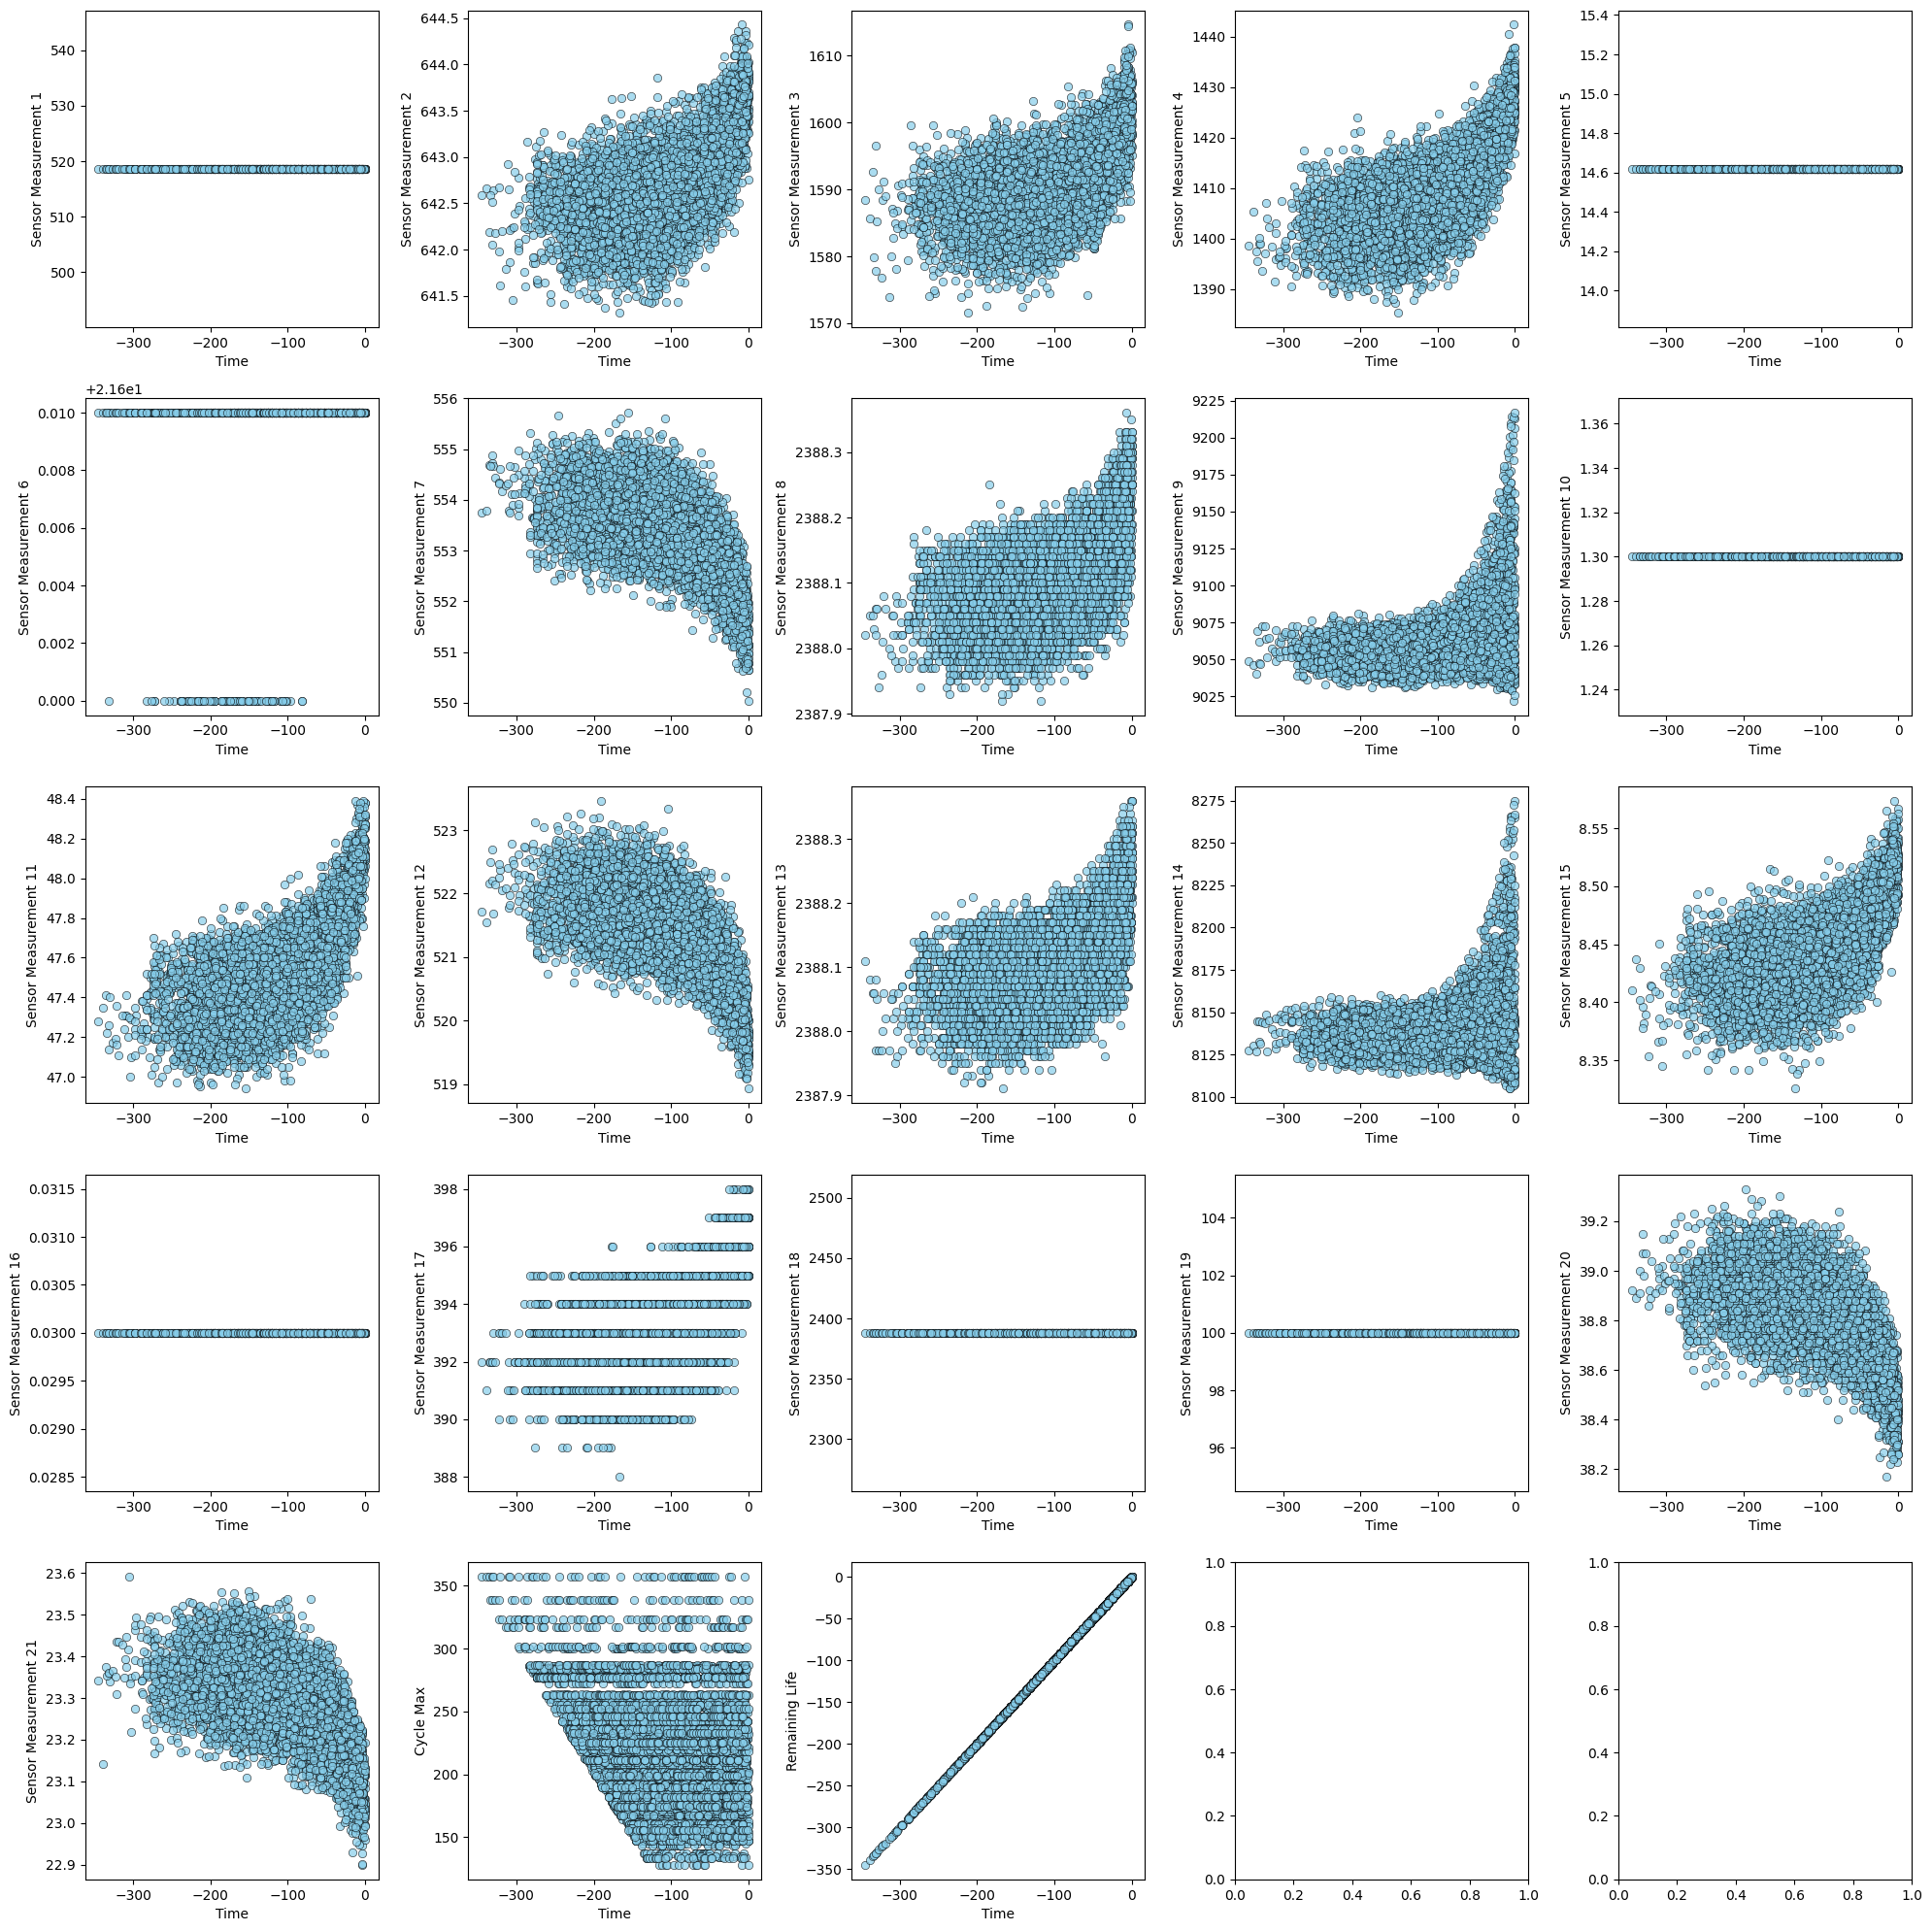

In [14]:
# Plot Remaining Life vs Sensor Measurement of all units and cluster 0

fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(20, 20)) 

for i in range(len(train.columns)-5):
    # Scatter plot on the ith subplot on cluster 0
    axs[i//5, i-(i//5)*5].scatter(train[train['cluster'] == 0]['Remaining Life'], train[train['cluster'] == 0][train.columns[i+4]], 
                   color='skyblue', alpha=0.7, edgecolors='black', linewidths=0.5)
    axs[i//5, i-(i//5)*5].set_xlabel('Time')
    axs[i//5, i-(i//5)*5].set_ylabel(train.columns[i+4])

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

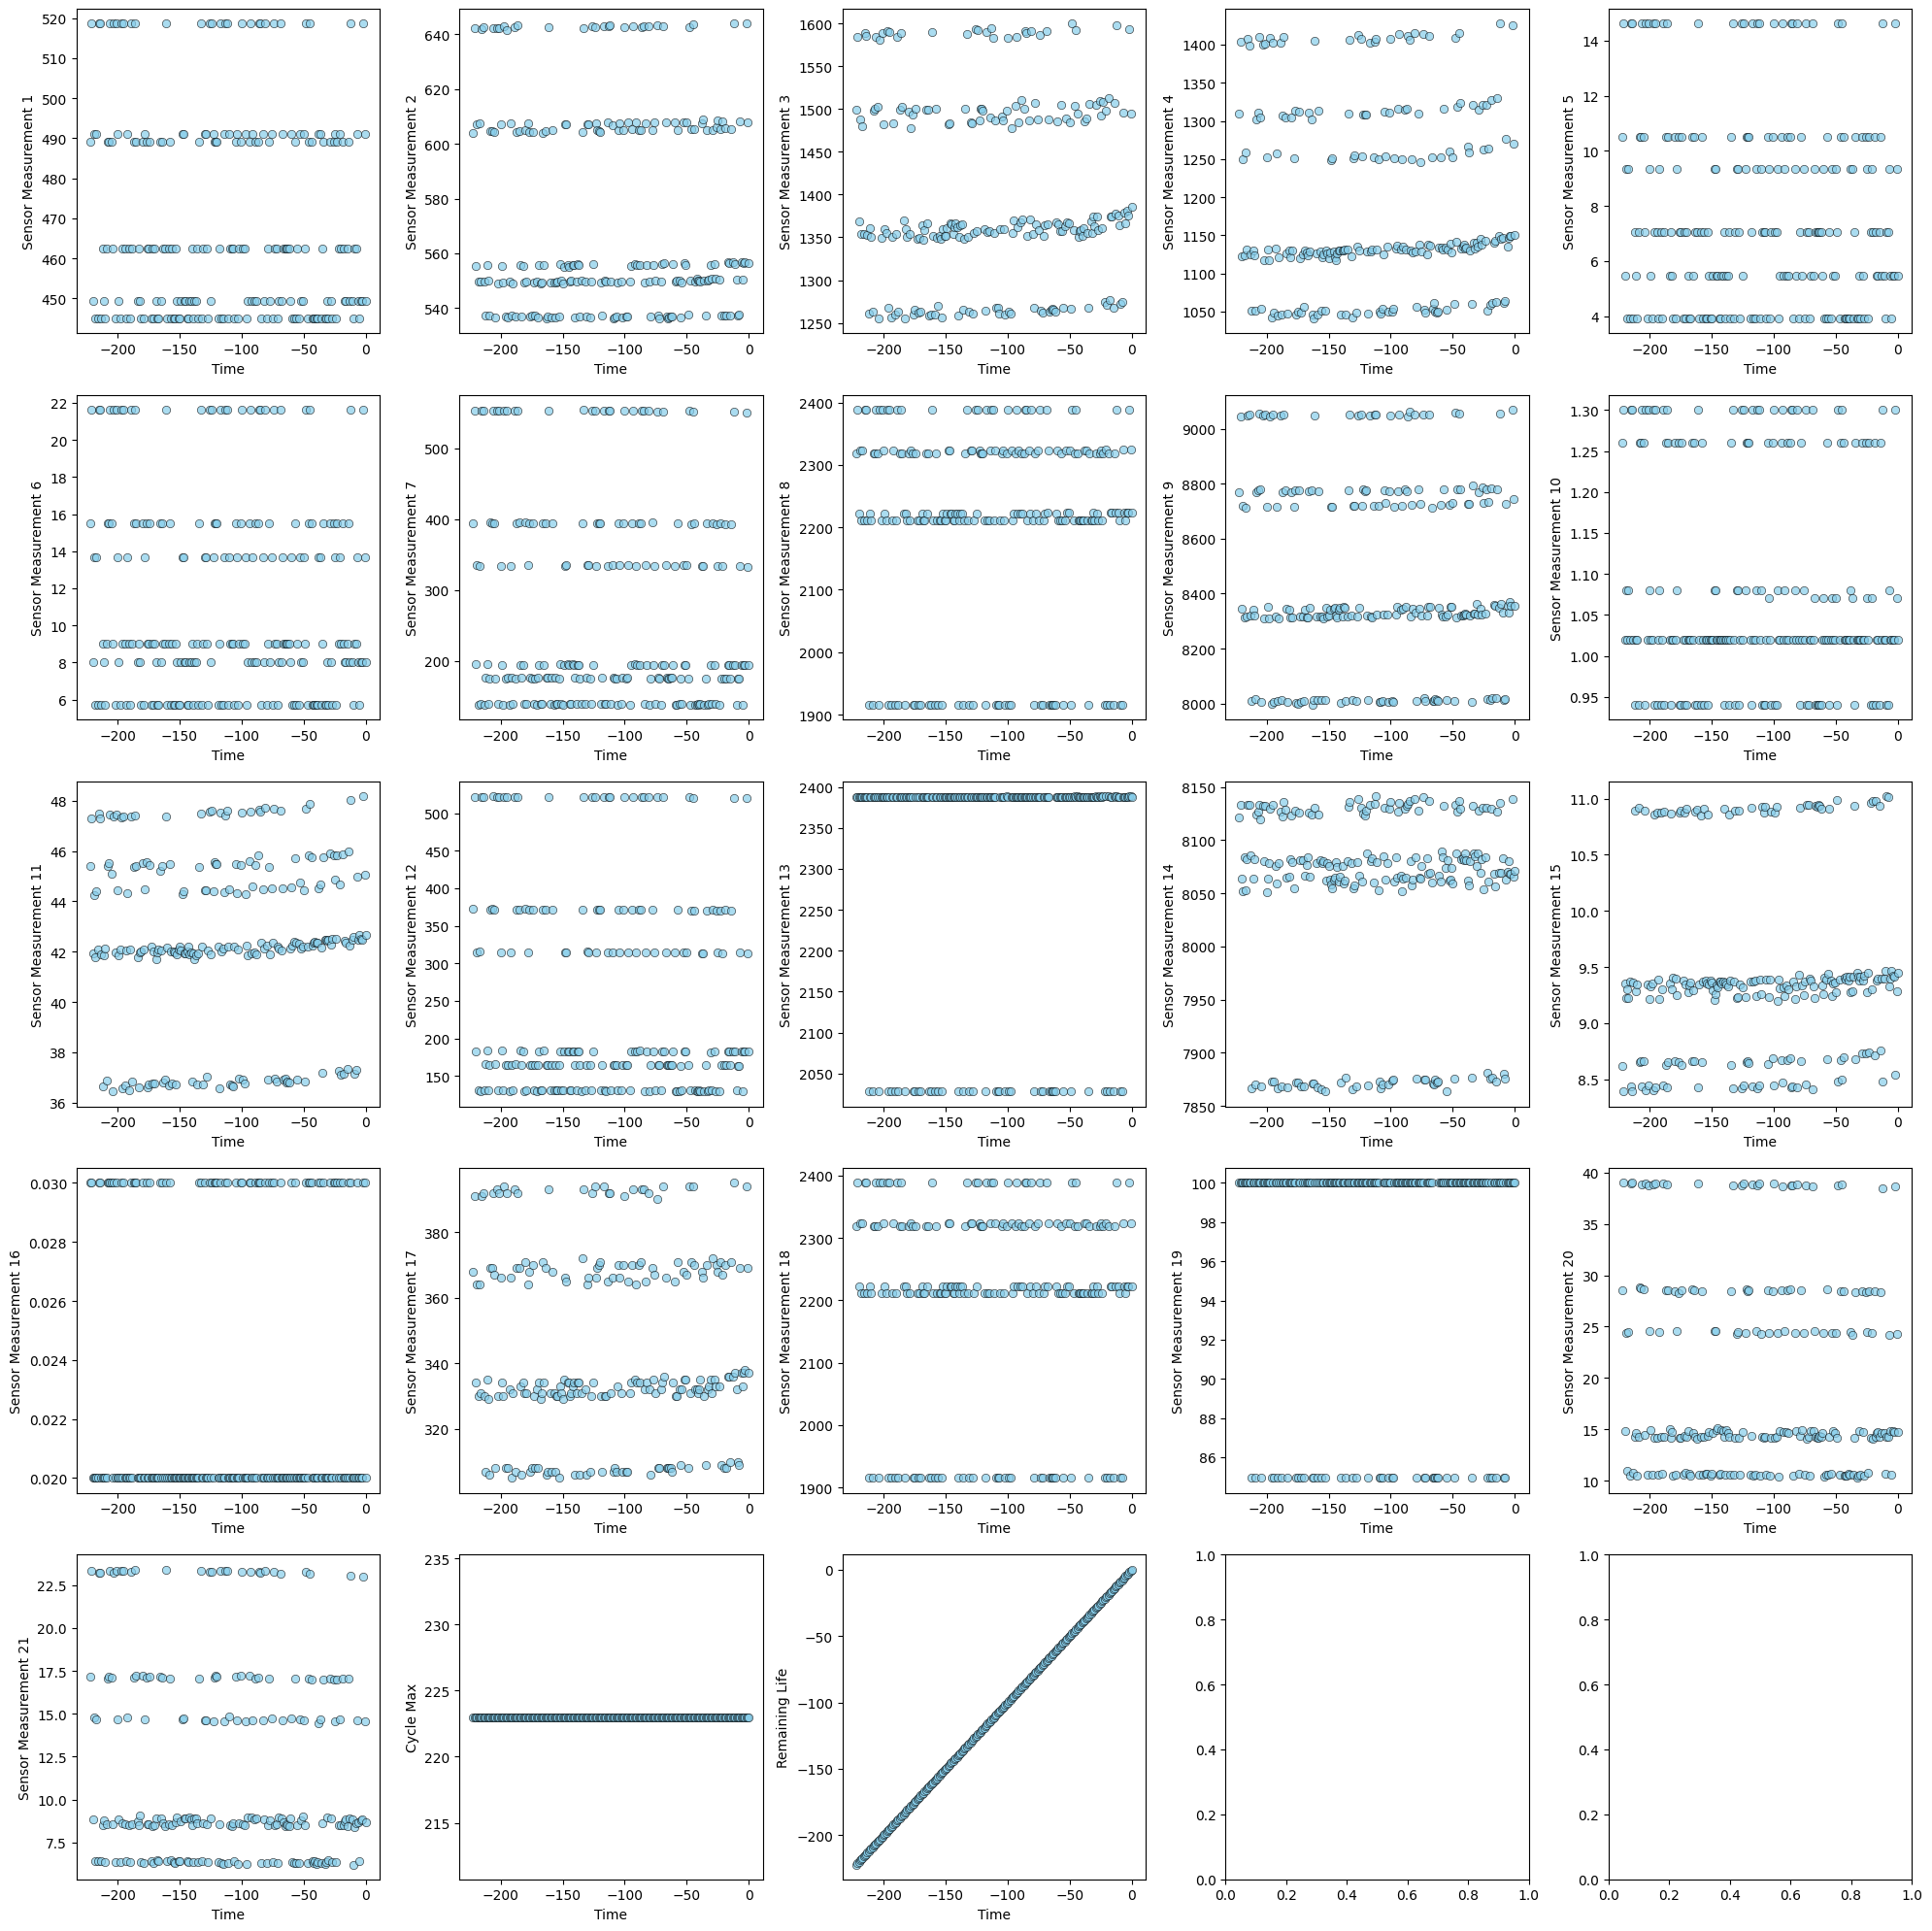

In [15]:
# Plot Remaining Life vs Sensor Measurement of Unit 1 and all clusters

fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(20, 20)) 

for i in range(len(train.columns)-5):
    # Scatter plot on the ith subplot on cluster 0
    axs[i//5, i-(i//5)*5].scatter(train.loc[1]['Remaining Life'], train.loc[1][train.columns[i+4]], 
                   color='skyblue', alpha=0.7, edgecolors='black', linewidths=0.5)
    axs[i//5, i-(i//5)*5].set_xlabel('Time')
    axs[i//5, i-(i//5)*5].set_ylabel(train.columns[i+4])

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

## Data preprocessing

In [88]:
train.index.unique() 

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       209, 210, 211, 212, 213, 214, 215, 216, 217, 218],
      dtype='int64', name='Unit Number', length=218)

In [97]:
# Split data set by units
units = train.index.unique()    # all engine IDs
print(f"Total engines: {len(units)}")

# First split into train+val vs test
train_units, val_units = train_test_split(units, test_size=0.1, random_state=42)

Total engines: 218


In [98]:
# Split data set into training and test sets
# Apply random seed to allow repetition of output

train_set = train[train.index.isin(train_units)].copy()
val_set   = train[train.index.isin(val_units)].copy()

In [99]:
# Apply Standard Scaler by cluster to transform the scaling of different features into similar scales.
unique_clusters = train_set['cluster'].unique().tolist()

cluster_mean= pd.DataFrame()
cluster_std= pd.DataFrame()

for i in range(len(unique_clusters)):
    cluster_mean['Cluster ' + str(i+1)] = train_set[train_set['cluster'] == i].mean()
    cluster_std['Cluster ' + str(i+1)] = train_set[train_set['cluster'] == i].std()

cluster_mean = cluster_mean.transpose()
cluster_std = cluster_std.transpose()


In [100]:
# Get normalized sensor measurement - training set
train_scaled_temp= pd.DataFrame()
train_scaled= pd.DataFrame()

for i in range(len(unique_clusters)):
    train_scaled_temp = (train_set[train_set['cluster'] == i] - cluster_mean.loc['Cluster ' + str(i+1)]) / cluster_std.loc['Cluster ' + str(i+1)]
    train_scaled_temp['Time, in cycles Reference'] = train_set[train_set['cluster'] == i]['Time, in cycles']
    train_scaled_temp['Remaining Life Reference'] = train_set[train_set['cluster'] == i]['Remaining Life']
    train_scaled_temp['Cluster Reference'] = train_set[train_set['cluster'] == i]['cluster']
    train_scaled = pd.concat([train_scaled, train_scaled_temp], axis=0)
train_scaled = train_scaled.drop(["Time, in cycles", "Operational Setting 1", "Operational Setting 2", "Operational Setting 3", 
                                  "cluster", "Cycle Max", "Remaining Life"], axis=1)
train_scaled = train_scaled.fillna(0)
train_scaled.rename(columns={'Remaining Life Reference': 'Remaining Life', 'Time, in cycles Reference': 'Time, in cycles', 
                             'Cluster Reference': 'Cluster'}, inplace=True)
train_scaled = train_scaled.sort_values(by='Time, in cycles')
train_scaled

,Sensor Measurement 1,Sensor Measurement 2,Sensor Measurement 3,Sensor Measurement 4,Sensor Measurement 5,Sensor Measurement 6,Sensor Measurement 7,Sensor Measurement 8,Sensor Measurement 9,Sensor Measurement 10,...,Sensor Measurement 15,Sensor Measurement 16,Sensor Measurement 17,Sensor Measurement 18,Sensor Measurement 19,Sensor Measurement 20,Sensor Measurement 21,"Time, in cycles",Remaining Life,Cluster
Unit Number,,,,,,,,,,,,,,,,,,,,,
168,0.000000,-1.392621,0.249296,-0.153453,0.999952,-1.176191,-2.396462,-0.823513,-0.775022,-0.146251,...,-0.819733,0.999952,-0.095406,0.0,0.0,2.662359,-0.891892,1,-252.0,3
134,-0.999920,-0.279285,0.523936,-0.051905,-0.999920,0.113905,-0.094378,0.225009,-0.687829,-0.999920,...,-0.328432,-0.999920,0.493992,0.0,0.0,1.040350,-0.463164,1,-172.0,0
102,0.999918,-1.123945,0.076263,-1.194062,-0.999918,-0.173917,1.143786,-0.517681,-0.633264,-0.174910,...,-1.084346,0.999918,-1.633540,0.0,0.0,-0.510964,1.348907,1,-221.0,1
198,0.999918,-0.486939,-0.631618,-0.199024,0.999918,-1.487113,2.411411,-0.474023,-0.693491,0.555970,...,-1.896706,-0.547834,-1.716461,0.0,0.0,2.208433,0.197065,1,-136.0,5
161,0.999918,-1.215010,0.220676,0.182938,-0.999918,-0.173917,1.417546,-0.695064,-0.591912,-0.174910,...,-0.600591,0.999918,-0.919863,0.0,0.0,-0.689017,0.418860,1,-183.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,0.000000,2.471547,1.340168,2.058341,0.999952,0.850120,0.008477,2.093671,2.754385,-0.146251,...,2.041219,0.999952,3.448785,0.0,0.0,2.198711,-1.073830,353,-4.0,3
5,0.999918,1.353197,1.745238,1.212527,0.999918,0.670268,-1.259862,3.351739,2.538561,-1.798361,...,1.856253,1.825070,1.797116,0.0,0.0,-0.953132,-2.641485,354,-3.0,5
5,-0.999918,1.519672,1.331107,1.780703,0.999918,1.428767,-2.500224,2.007804,2.934786,0.999918,...,2.290431,-0.999918,2.912796,0.0,0.0,-0.172869,-2.623905,355,-2.0,2


In [101]:
# Get normalized sensor measurement - validation set


In [102]:
# Convert training and test dataset into x and y

xtrain = train_scaled.drop(["Remaining Life"], axis=1)
ytrain = train_scaled["Remaining Life"]

# xtest = val_scaled.drop(["Remaining Life"], axis=1)
# ytest = val_scaled["Remaining Life"]

In [103]:
# Trandability analysis


# Construct Asset Health Indicator

In [104]:
xtrain

,Sensor Measurement 1,Sensor Measurement 2,Sensor Measurement 3,Sensor Measurement 4,Sensor Measurement 5,Sensor Measurement 6,Sensor Measurement 7,Sensor Measurement 8,Sensor Measurement 9,Sensor Measurement 10,...,Sensor Measurement 14,Sensor Measurement 15,Sensor Measurement 16,Sensor Measurement 17,Sensor Measurement 18,Sensor Measurement 19,Sensor Measurement 20,Sensor Measurement 21,"Time, in cycles",Cluster
Unit Number,,,,,,,,,,,,,,,,,,,,,
168,0.000000,-1.392621,0.249296,-0.153453,0.999952,-1.176191,-2.396462,-0.823513,-0.775022,-0.146251,...,-0.610041,-0.819733,0.999952,-0.095406,0.0,0.0,2.662359,-0.891892,1,3
134,-0.999920,-0.279285,0.523936,-0.051905,-0.999920,0.113905,-0.094378,0.225009,-0.687829,-0.999920,...,-0.632447,-0.328432,-0.999920,0.493992,0.0,0.0,1.040350,-0.463164,1,0
102,0.999918,-1.123945,0.076263,-1.194062,-0.999918,-0.173917,1.143786,-0.517681,-0.633264,-0.174910,...,-0.566027,-1.084346,0.999918,-1.633540,0.0,0.0,-0.510964,1.348907,1,1
198,0.999918,-0.486939,-0.631618,-0.199024,0.999918,-1.487113,2.411411,-0.474023,-0.693491,0.555970,...,-0.216496,-1.896706,-0.547834,-1.716461,0.0,0.0,2.208433,0.197065,1,5
161,0.999918,-1.215010,0.220676,0.182938,-0.999918,-0.173917,1.417546,-0.695064,-0.591912,-0.174910,...,-0.673092,-0.600591,0.999918,-0.919863,0.0,0.0,-0.689017,0.418860,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,0.000000,2.471547,1.340168,2.058341,0.999952,0.850120,0.008477,2.093671,2.754385,-0.146251,...,2.674592,2.041219,0.999952,3.448785,0.0,0.0,2.198711,-1.073830,353,3
5,0.999918,1.353197,1.745238,1.212527,0.999918,0.670268,-1.259862,3.351739,2.538561,-1.798361,...,2.572088,1.856253,1.825070,1.797116,0.0,0.0,-0.953132,-2.641485,354,5
5,-0.999918,1.519672,1.331107,1.780703,0.999918,1.428767,-2.500224,2.007804,2.934786,0.999918,...,2.519778,2.290431,-0.999918,2.912796,0.0,0.0,-0.172869,-2.623905,355,2


In [105]:
# # Plot Remaining Life vs Normalised Sensor Measurement of all units

# fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(20, 20)) 
# cmap = plt.get_cmap('tab10')  # 'tab10' has 10 distinct colors
# colors = [cmap(i) for i in range(6)]  # get first 6 colors

# # for i in range(len(train_scaled.columns)-1):
# for i in range(4):
#     # Scatter plot on the ith subplot on cluster 0
#     for j in range(len(unique_clusters)):
#         axs[i].plot(xtrain[xtrain['Cluster']==j]['Time, in cycles'], xtrain[xtrain['Cluster']==j][xtrain.columns[i]], 
#                        color=colors[j], alpha=0.7)
#         # axs[i].scatter(ytrain[xtrain['Cluster']==j], xtrain[xtrain['Cluster']==j][xtrain.columns[i]], 
#         #        color=colors[j], alpha=0.7, edgecolors='black', linewidths=0.5)
#         axs[i].set_xlabel('Time, in cycles')
#         axs[i].set_ylabel(train_scaled.columns[i])

# # Adjust layout to prevent overlapping titles/labels
# plt.tight_layout()

In [106]:
xtrain = train_scaled.drop(["Remaining Life", "Time, in cycles", "Cluster"], axis=1)


In [ ]:
# # Linear Regression Basic Implementation 
# model = LinearRegression()
# slope = []

# for column in xtrain.columns:
#     x_sensor = xtrain[[column]]
#     model.fit(x_sensor, ytrain)
#     slope.append((model.coef_[0], column))
#     print(column, model.coef_[0])
# slope = sorted(slope, reverse=True)[:5]
# selected_sensors = [i[1] for i in slope]
# selected_sensors
# # # Predict on test set
# # y_pred = model.predict(xtest)

Sensor Measurement 1 0.7027886613705342
Sensor Measurement 2 37.932431326452836
Sensor Measurement 3 37.48508877688653
Sensor Measurement 4 44.74015048428249
Sensor Measurement 5 -0.161546994254214
Sensor Measurement 6 22.845266514815165
Sensor Measurement 7 -30.375735636457158
Sensor Measurement 8 28.810232913524683
Sensor Measurement 9 26.365783245060936
Sensor Measurement 10 -2.336144476169841
Sensor Measurement 11 46.75714549682405
Sensor Measurement 12 -32.174724392665055
Sensor Measurement 13 28.938937044645925
Sensor Measurement 14 20.47675641462308
Sensor Measurement 15 43.51255731471398
Sensor Measurement 16 6.4718749504451605
Sensor Measurement 17 39.3230712577151
Sensor Measurement 18 0.0
Sensor Measurement 19 0.6819842582164585
Sensor Measurement 20 -28.634682958112563
Sensor Measurement 21 -29.233898099457544


['Sensor Measurement 11',
 'Sensor Measurement 4',
 'Sensor Measurement 15',
 'Sensor Measurement 17',
 'Sensor Measurement 2']

In [108]:
ytrain

Unit Number
168   -252.0
134   -172.0
102   -221.0
198   -136.0
161   -183.0
       ...  
5       -4.0
5       -3.0
5       -2.0
5       -1.0
5        0.0
Name: Remaining Life, Length: 41138, dtype: float64

In [109]:
# # Plot Remaining Life vs Normalised Sensor Measurement of all units

# fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(20, 20)) 
# cmap = plt.get_cmap('tab10')  # 'tab10' has 10 distinct colors
# colors = [cmap(i) for i in range(6)]  # get first 6 colors

# # for i in range(len(train_scaled.columns)-1):
# for i in range(4):
#     # Scatter plot on the ith subplot on cluster 0
#     for j in range(len(unique_clusters)):
#         axs[i].plot(xtrain[xtrain['Cluster']==j]['Time, in cycles'], xtrain[xtrain['Cluster']==j][xtrain.columns[i]], 
#                        color=colors[j], alpha=0.7)
#         # axs[i].scatter(ytrain[xtrain['Cluster']==j], xtrain[xtrain['Cluster']==j][xtrain.columns[i]], 
#         #        color=colors[j], alpha=0.7, edgecolors='black', linewidths=0.5)
#         axs[i].set_xlabel('Time, in cycles')
#         axs[i].set_ylabel(train_scaled.columns[i])

# # Adjust layout to prevent overlapping titles/labels
# plt.tight_layout()

In [110]:
ytrain.shape

(41138,)

In [111]:
x_sensor = train_scaled[selected_sensors]
train_scaled

,Sensor Measurement 1,Sensor Measurement 2,Sensor Measurement 3,Sensor Measurement 4,Sensor Measurement 5,Sensor Measurement 6,Sensor Measurement 7,Sensor Measurement 8,Sensor Measurement 9,Sensor Measurement 10,...,Sensor Measurement 15,Sensor Measurement 16,Sensor Measurement 17,Sensor Measurement 18,Sensor Measurement 19,Sensor Measurement 20,Sensor Measurement 21,"Time, in cycles",Remaining Life,Cluster
Unit Number,,,,,,,,,,,,,,,,,,,,,
168,0.000000,-1.392621,0.249296,-0.153453,0.999952,-1.176191,-2.396462,-0.823513,-0.775022,-0.146251,...,-0.819733,0.999952,-0.095406,0.0,0.0,2.662359,-0.891892,1,-252.0,3
134,-0.999920,-0.279285,0.523936,-0.051905,-0.999920,0.113905,-0.094378,0.225009,-0.687829,-0.999920,...,-0.328432,-0.999920,0.493992,0.0,0.0,1.040350,-0.463164,1,-172.0,0
102,0.999918,-1.123945,0.076263,-1.194062,-0.999918,-0.173917,1.143786,-0.517681,-0.633264,-0.174910,...,-1.084346,0.999918,-1.633540,0.0,0.0,-0.510964,1.348907,1,-221.0,1
198,0.999918,-0.486939,-0.631618,-0.199024,0.999918,-1.487113,2.411411,-0.474023,-0.693491,0.555970,...,-1.896706,-0.547834,-1.716461,0.0,0.0,2.208433,0.197065,1,-136.0,5
161,0.999918,-1.215010,0.220676,0.182938,-0.999918,-0.173917,1.417546,-0.695064,-0.591912,-0.174910,...,-0.600591,0.999918,-0.919863,0.0,0.0,-0.689017,0.418860,1,-183.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,0.000000,2.471547,1.340168,2.058341,0.999952,0.850120,0.008477,2.093671,2.754385,-0.146251,...,2.041219,0.999952,3.448785,0.0,0.0,2.198711,-1.073830,353,-4.0,3
5,0.999918,1.353197,1.745238,1.212527,0.999918,0.670268,-1.259862,3.351739,2.538561,-1.798361,...,1.856253,1.825070,1.797116,0.0,0.0,-0.953132,-2.641485,354,-3.0,5
5,-0.999918,1.519672,1.331107,1.780703,0.999918,1.428767,-2.500224,2.007804,2.934786,0.999918,...,2.290431,-0.999918,2.912796,0.0,0.0,-0.172869,-2.623905,355,-2.0,2


In [112]:
selected_sensors

['Sensor Measurement 11',
 'Sensor Measurement 4',
 'Sensor Measurement 15',
 'Sensor Measurement 17',
 'Sensor Measurement 2']

In [ ]:
# x_sensor = train_scaled[selected_sensors]
rul_per_unit = train_scaled.groupby('Unit Number')['Time, in cycles'].max().reset_index()
rul_per_unit.columns = ["Unit Number", "max_cycle"]
x_sensor = train_scaled.merge(rul_per_unit, on="Unit Number", how="left")
x_sensor["RUL"] = x_sensor["max_cycle"] - x_sensor["Time, in cycles"]
x_sensor["Health Condition"] = x_sensor["RUL"] / x_sensor["max_cycle"]
x_sensor = x_sensor.sort_values(by=['Unit Number', 'Time, in cycles'])
y_sensor = x_sensor['RUL'].to_frame()
x_sensor = x_sensor.drop(["Time, in cycles", "Remaining Life", "Cluster", "max_cycle"], axis=1)
x_sensor = x_sensor.set_index("Unit Number")
y_sensor

,RUL
26,222
198,221
447,220
750,219
963,218
...,...
25167,4
25403,3
25573,2
25819,1


In [129]:
x_sensor[x_sensor.index == 1][x_sensor.columns[0]]

Unit Number
1   -0.999918
1   -0.999920
1    0.999918
1    0.999918
1    0.000000
       ...   
1    0.999918
1    0.999918
1   -0.999920
1    0.999918
1    0.999918
Name: Sensor Measurement 1, Length: 223, dtype: float64

In [144]:
# Linear Regression on each sensor for RUL
fusion_model = LinearRegression()
slope = []

for sensor in x_sensor.columns:
    if "Sensor Measurement" in sensor:
        sensor_slope = []
        for unit in x_sensor.index.unique():
            x = x_sensor[x_sensor.index == unit][sensor].to_frame()
            y = x_sensor[x_sensor.index == unit]['RUL'].to_frame()
            fusion_model.fit(x, y)
            fusion_model.coef_[0]
            sensor_slope.append(fusion_model.coef_[0])
        sensor_median = np.abs(float(np.median(sensor_slope)))
        slope.append((sensor_median, sensor))
        print(sensor, sensor_median)
slope = sorted(slope, reverse=True)[:8]
selected_sensors = [i[1] for i in slope]
selected_sensors
# # Predict on test set
# y_pred = model.predict(xtest)

Sensor Measurement 1 0.4587963457714166
Sensor Measurement 2 38.72001188812844
Sensor Measurement 3 37.8969894500998
Sensor Measurement 4 48.44882799088536
Sensor Measurement 5 0.029323038655221102
Sensor Measurement 6 23.04299328461329
Sensor Measurement 7 30.638130856004594
Sensor Measurement 8 33.44282705148149
Sensor Measurement 9 49.65981208552627
Sensor Measurement 10 5.215230463056804
Sensor Measurement 11 53.10137326782444
Sensor Measurement 12 33.18252570879133
Sensor Measurement 13 33.61934941058972
Sensor Measurement 14 39.43563311847207
Sensor Measurement 15 47.9658134732352
Sensor Measurement 16 5.378340931338722
Sensor Measurement 17 39.8689276620988
Sensor Measurement 18 0.0
Sensor Measurement 19 0.03925367733330616
Sensor Measurement 20 27.889422830184216
Sensor Measurement 21 28.47343882865436


['Sensor Measurement 11',
 'Sensor Measurement 9',
 'Sensor Measurement 4',
 'Sensor Measurement 15',
 'Sensor Measurement 17',
 'Sensor Measurement 14',
 'Sensor Measurement 2',
 'Sensor Measurement 3']

In [ ]:
# Linear Regression for fused sensor
model = LinearRegression()
slope = []

x = x_sensor[selected_sensors]
y= x_sensor["Health Indicator"]
model.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [153]:
# Evaluate the model
for i in range(len(selected_sensors)):
    print(selected_sensors[i],  model.coef_[i])
print("Intercept:", model.intercept_)
print("Slope:", model.coef_)

Sensor Measurement 11 -0.07656216372172522
Sensor Measurement 9 -0.04755205255539764
Sensor Measurement 4 -0.049276205182216176
Sensor Measurement 15 -0.04659866101999941
Sensor Measurement 17 -0.025434159851129203
Sensor Measurement 14 -0.017328909680615533
Sensor Measurement 2 -0.022567064910334368
Sensor Measurement 3 -0.019939683088089938
Intercept: 0.4976177743205798
Slope: [-0.07656216 -0.04755205 -0.04927621 -0.04659866 -0.02543416 -0.01732891
 -0.02256706 -0.01993968]


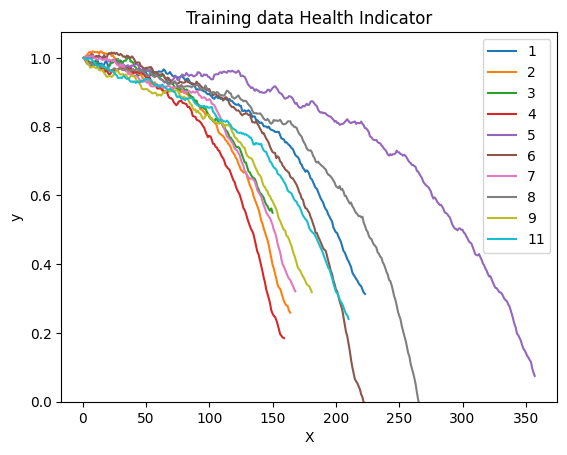

In [208]:
for i in x_sensor.index.unique()[:10]:
    out = x_sensor[x_sensor.index == i][selected_sensors].values @ model.coef_
    out = pd.Series(out).rolling(window=21, center=True, min_periods=1).mean().values
    out = out + 1.0 - out[0]
    # Plot
    plt.plot(np.arange(1, len(out)+1), out, label=i)       # actual data points
plt.xlabel('X')
plt.ylabel('y')
plt.ylim(0)
plt.legend()
plt.title('Training data Health Indicator')
plt.show()

In [ ]:
# Predict on test set
y_pred = model.predict(xtest)